# 09 — `src/models/lstm_model.py`: The Deep Learning Comparison Model

CLAUDE.md names XGBoost as the favored *default* for a dataset this size, but asks for an LSTM built alongside it — partly to demonstrate the deep-learning approach, and partly because the project owner is explicitly learning ML/DL concepts and wants a real side-by-side comparison, not just a claim that "XGBoost is better." This notebook walks through the LSTM end to end, including two design choices that make it a genuinely *different* approach to the same ordinal problem, not just "the same idea in PyTorch."

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.models import lstm_model
from src.config import PROCESSED_DIR, SEVERITY_TIERS, N_TIERS

## Different input than XGBoost, on purpose

```python
LSTM_RAW_COLUMNS = ["spo2", "hr", "temp", "altitude"]
```

XGBoost trains on `FEATURE_COLUMNS`, which includes hand-engineered features like `spo2_trend_5min` and `spo2_delta` — a human (well, the code in `feature_engineering.py`) computed "the trend" and handed it to the model as a ready-made number. The LSTM instead gets only the **raw** vitals at each timestep — no trend, no delta, no engineered anything — over a **60-second sliding window**. The idea being tested: can a recurrent network learn "this is trending downward" *by itself*, from watching the raw sequence, the way XGBoost needed a human to compute that explicitly? This is the actual point of the comparison — not just "which number is bigger," but which *strategy* (hand-engineered features + a tree ensemble, vs. raw sequences + learned temporal representation) works better on this data.

## Windowing: strided, not every-second

```python
WINDOW_SAMPLES = LSTM_WINDOW_SECONDS * SAMPLE_RATE_HZ   # = 60
STRIDE_SECONDS = 15   # take a window every 15s, not every 1s
```

Naively, you might slide the 60-second window forward one second at a time across every trajectory. At 1Hz over 400 subjects × 90 minutes each (~2.16 million rows), that would produce roughly 2 million windows — and consecutive windows one second apart share 59 of their 60 samples, making them >98% identical. Training on that would be extremely slow for essentially zero added information (the model would see nearly the same window thousands of times with a tiny shift). Striding by 15 seconds instead keeps window diversity high per unit of training time — each window overlaps its neighbor by 45/60 samples instead of 59/60, a meaningfully different sequence.

In [2]:
train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
val_df = pd.read_csv(PROCESSED_DIR / "val.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")

# Estimate how many windows the stride actually produces, vs. the naive every-second approach
one_subject = train_df[train_df["subject_id"] == train_df["subject_id"].iloc[0]]
n_rows = len(one_subject)
naive_windows = max(0, n_rows - lstm_model.WINDOW_SAMPLES + 1)
strided_windows = len(range(0, n_rows - lstm_model.WINDOW_SAMPLES + 1, lstm_model.STRIDE_SECONDS))

print(f"One subject's trajectory: {n_rows} rows")
print(f"Naive (every-second) windows: {naive_windows:,}")
print(f"Strided (every {lstm_model.STRIDE_SECONDS}s) windows: {strided_windows:,}")
print(f"Reduction: ~{naive_windows/max(strided_windows,1):.0f}x fewer windows, for minimal loss of diversity")

One subject's trajectory: 5400 rows
Naive (every-second) windows: 5,341
Strided (every 15s) windows: 357
Reduction: ~15x fewer windows, for minimal loss of diversity


## `build_windows()`: what each window is labeled with

```python
def build_windows(df):
    for _subject_id, group in df.groupby("subject_id"):
        ...
        for start in range(0, n - WINDOW_SAMPLES + 1, STRIDE_SECONDS * SAMPLE_RATE_HZ):
            end = start + WINDOW_SAMPLES
            X_windows.append(values[start:end])
            y_windows.append(labels[end - 1])   # label = severity at the LAST timestep
```

Each window is labeled with the severity at its **final** timestep, not some average or the label at the start. The framing is: "given the last 60 seconds of vitals, what's the severity **right now**?" — which mirrors exactly how this model would be used live (Stage 4 of the data flow diagram: fed the trailing buffer, asked for the current classification). Grouping by `subject_id` first, and only sliding within a single subject's rows, guarantees a window never accidentally blends the end of one subject's trajectory with the start of another's.

In [3]:
X_train, y_train = lstm_model.build_windows(train_df)
X_val, y_val = lstm_model.build_windows(val_df)
print(f"Train windows: {X_train.shape}  (n_windows, seq_len={X_train.shape[1]}, n_features={X_train.shape[2]})")
print(f"Val windows:   {X_val.shape}")
print()
print("Label distribution across train windows:")
print(pd.Series(y_train).map(dict(enumerate(SEVERITY_TIERS))).value_counts())

Train windows: (99246, 60, 4)  (n_windows, seq_len=60, n_features=4)
Val windows:   (20349, 60, 4)

Label distribution across train windows:
Normal        58905
Mild AMS      16779
Severe AMS    13209
HAPE risk      5712
HACE risk      4641
Name: count, dtype: int64


## Normalization: fit on train only

```python
mean = X_train.reshape(-1, X_train.shape[-1]).mean(axis=0)
std = X_train.reshape(-1, X_train.shape[-1]).std(axis=0) + 1e-6
```

Same leakage principle you saw in `feature_engineering.py`'s temporal split, applied to normalization: the mean/std used to scale every input feature are computed **only from the training windows**, then applied unchanged to validation and test. If we instead computed separate normalization stats per split (or on the combined data), information about the val/test distribution would leak into what the model implicitly "knows" through the scaling itself — a subtle form of the same leakage problem, just at the preprocessing stage instead of the split stage.

In [4]:
mean = X_train.reshape(-1, X_train.shape[-1]).mean(axis=0)
std = X_train.reshape(-1, X_train.shape[-1]).std(axis=0) + 1e-6  # avoid divide-by-zero

for col, m, s in zip(lstm_model.LSTM_RAW_COLUMNS, mean, std):
    print(f"  {col:10s}  mean={m:8.2f}  std={s:7.2f}")

  spo2        mean=   89.72  std=   6.05
  hr          mean=   78.82  std=  15.81
  temp        mean=   35.58  std=   1.15
  altitude    mean= 3234.24  std=1216.24


## The model architecture: `SeverityLSTM`

```python
class SeverityLSTM(nn.Module):
    def __init__(self, n_features, hidden_size=48, n_layers=2):
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_size,
                             num_layers=n_layers, batch_first=True, dropout=0.2)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, N_TIERS)
        )

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.head(h_n[-1])   # classify from the FINAL hidden state
```

Deliberately small — 2 LSTM layers, 48 hidden units — per CLAUDE.md's explicit instruction to keep this a comparison model, not a bid for maximum performance. A larger model on a dataset this size would risk overfitting long before it found any real advantage over XGBoost.

**How it processes a window:** the LSTM reads the 60-timestep sequence one step at a time, updating its internal hidden state as it goes. We only use the **final** hidden state (`h_n[-1]`, the state after having seen all 60 seconds) as the summary of "what happened in this window," which then feeds into a small classifier head (`Linear -> ReLU -> Dropout -> Linear`) that outputs one score per severity tier.

**A key strategic difference from XGBoost, worth sitting with:** this classifies directly into 5 categories using cross-entropy loss — it does **not** use XGBoost's regression trick. This is a genuine difference in how the two models handle "ordinal-ness": XGBoost enforces it structurally (via the regression target, tier distance is baked into the loss). The LSTM instead only gets class weighting to handle imbalance, with no explicit mechanism telling it that tier 3 and tier 4 are "close." Comparing the two isn't just "which one wins" — it's informative about whether that structural ordinal-awareness actually mattered, which is exactly the kind of question `mean_abs_tier_error` (not just accuracy) is designed to answer.

In [5]:
model = lstm_model.SeverityLSTM(n_features=len(lstm_model.LSTM_RAW_COLUMNS))
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal trainable parameters: {n_params:,}  (deliberately small)")

SeverityLSTM(
  (lstm): LSTM(4, 48, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=48, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=5, bias=True)
  )
)

Total trainable parameters: 30,917  (deliberately small)


## Class-weighted loss — same idea as XGBoost, different mechanism

```python
class_counts = np.bincount(y_train, minlength=N_TIERS).astype(np.float32)
class_weights = class_counts.sum() / (N_TIERS * np.clip(class_counts, 1, None))
criterion = nn.CrossEntropyLoss(weight=torch.from_numpy(class_weights))
```

Same goal as XGBoost's `compute_sample_weight("balanced", ...)` — rare classes shouldn't get drowned out by "Normal" — but implemented as **class weights baked into the loss function** rather than per-row sample weights. `CrossEntropyLoss(weight=...)` multiplies each class's contribution to the loss by its weight, so a wrong prediction on a rare HACE-risk window costs more than an equally-wrong prediction on an abundant Normal window.

In [6]:
class_counts = np.bincount(y_train, minlength=N_TIERS).astype(np.float32)
class_weights = class_counts.sum() / (N_TIERS * np.clip(class_counts, 1, None))

for tier, count, weight in zip(SEVERITY_TIERS, class_counts, class_weights):
    print(f"  {tier:12s}  n={int(count):>6,}  loss_weight={weight:.3f}")

  Normal        n=58,905  loss_weight=0.337
  Mild AMS      n=16,779  loss_weight=1.183
  Severe AMS    n=13,209  loss_weight=1.503
  HAPE risk     n= 5,712  loss_weight=3.475
  HACE risk     n= 4,641  loss_weight=4.277


## Training with early stopping

```python
for epoch in range(1, epochs + 1):
    ... train one epoch ...
    ... evaluate on val_loader ...
    if val_loss < best_val_loss:
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            break   # early stopping
```

Same principle as XGBoost's `early_stopping_rounds`, implemented by hand here since plain PyTorch doesn't have it built in: after each epoch, check validation loss. If it's the best seen so far, save a **copy** of the model's weights (`.clone()` — important, otherwise `best_state` would just keep pointing at the same tensors that get overwritten next epoch) and reset patience. If validation loss doesn't improve for `patience` (3) consecutive epochs, stop early and restore the best checkpoint — not whatever the final epoch happened to produce, which could already be overfitting.

Let's actually train it on the real data now — this takes a little while (a few dozen seconds on CPU, small model).

In [7]:
print("Training LSTM on real train/val windows...")
trained_model, mean, std = lstm_model.train(train_df, val_df)
print("Done.")

Training LSTM on real train/val windows...


LSTM windows -- train: 99,246, val: 20,349


  epoch  1/12  train_loss=1.4043  val_loss=1.1932


  epoch  2/12  train_loss=1.3211  val_loss=1.1178


  epoch  3/12  train_loss=1.2796  val_loss=1.1150


  epoch  4/12  train_loss=1.2536  val_loss=1.1906


  epoch  5/12  train_loss=1.2093  val_loss=1.1683


  epoch  6/12  train_loss=1.1803  val_loss=1.2031
  early stopping at epoch 6 (no val improvement for 3 epochs)
Done.


## Evaluating on the held-out test set

In [8]:
from src.models.metrics import evaluate, print_report

y_pred, y_true = lstm_model.predict(trained_model, mean, std, test_df)
result = evaluate(y_true, y_pred, model_name="LSTM (test set)")
print_report(result)


  LSTM (test set)
  Precision (macro):       0.4049
  Recall (macro):          0.3695
  F1 (macro):              0.3742
  Mean Abs Tier Error:     0.7849  (0 = perfect)
  Under-triage rate:       0.2345  (predicted too mild)

  Confusion matrix (rows=actual, cols=predicted):
            Normal  Mild AMS  Severe AMS  HAPE risk  HACE risk
Normal       11161       399          90       1030        529
Mild AMS      1806      1501         137        119        364
Severe AMS     972       758         809        462        212
HAPE risk      406       256         264         78        424
HACE risk      418       354         208          0        448



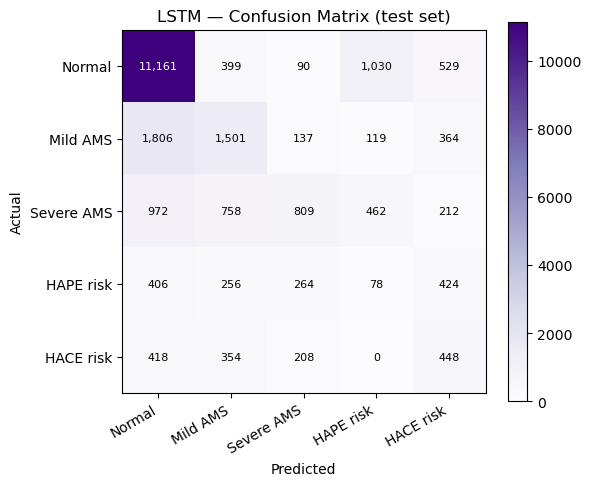

In [9]:
cm = result["confusion_matrix"]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Purples")
ax.set_xticks(range(len(SEVERITY_TIERS)), SEVERITY_TIERS, rotation=30, ha="right")
ax.set_yticks(range(len(SEVERITY_TIERS)), SEVERITY_TIERS)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("LSTM — Confusion Matrix (test set)")
for i in range(len(SEVERITY_TIERS)):
    for j in range(len(SEVERITY_TIERS)):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
fig.colorbar(im)
fig.tight_layout()
plt.show()

## What the comparison actually showed

From the Days 4-7 run (see `01_data_exploration.ipynb` for the recorded numbers): the LSTM's F1 (macro) came out essentially tied with XGBoost (~0.37 both), but its **Mean Absolute Tier Error was notably worse** (0.78 vs XGBoost's 0.59). Given both models were evaluated with the exact same `metrics.py` on the exact same test set, that gap is informative: it suggests XGBoost's structural approach to ordinality (regression target, tier distance baked into the loss) genuinely helped here, more than the LSTM's ability to learn temporal patterns directly from raw sequences compensated for. That's a real, useful finding — not just "XGBoost wins by default" but "the ordinal-aware training strategy mattered more than access to raw sequence data," on a dataset this size.

This isn't a permanent verdict on LSTMs vs gradient boosting in general — with more data, more careful architecture search, or an ordinal-aware loss function for the LSTM too (that's a legitimate future improvement, not built here per CLAUDE.md's "don't add models beyond this set" instruction), the LSTM might close the gap. But for *this* dataset, at *this* size, with *this* comparison, XGBoost's approach won on the metric that matters most clinically.

## Summary

The LSTM takes a genuinely different approach from XGBoost: raw 60-second windows instead of hand-engineered features, classification instead of regression, class-weighted cross-entropy instead of sample weighting. Built small and deliberately unambitious per CLAUDE.md, its purpose was never to win outright — it was to make the XGBoost-vs-LSTM comparison a real, informative one, which it did: comparable F1, worse ordinal-error, suggesting XGBoost's regression-based ordinal strategy is the better fit for this particular dataset size and shape.

**Next notebook:** `10_predict_severity.ipynb` — how the three models get compared side by side, and how the winner becomes the single `predict_severity()` function the rest of the system calls.